# Train various Logistic Regression models on KDDCup99 dataset: Lab 3
* Through this lab  there are a few observations to be made in regards to models such as no regularization, L2 and L2 regularization: 
    * L1 regularization have the heaviest weights on both train and test 
    * L2 and no regularization have slightly lower heaviest weights so that means L2 will have higher chance of reducing overfitting my makign the model more simple and seeing unseen data points.
    * In L2 with increase c value we observe that there test scores are higher as there is an increase of C value 
     


In [1]:
from sklearn import datasets
from sklearn import metrics
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("~/Desktop/kddcup99_csv.csv", on_bad_lines="skip")
df



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [2]:
df2 = df.copy()

df = df[df['label'] != "normal"]

X = df.iloc[: , :41]
y = df.iloc[:, 41:]

print(y)

IC = np.unique(y)

print(IC)

print(len(X))
print(len(y))

                  label
744     buffer_overflow
745     buffer_overflow
4049         loadmodule
4113               perl
7601            neptune
...                 ...
490959         teardrop
490960         teardrop
490961         teardrop
490962         teardrop
490963         teardrop

[396743 rows x 1 columns]
['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'perl' 'phf' 'pod'
 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop' 'warezclient'
 'warezmaster']
396743
396743


In [3]:
vals, df['label'] = np.unique(df['label'].values, return_inverse=True)

y = df.iloc[:, 41:]

print(vals)
print(y)

print(y.shape)



['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'perl' 'phf' 'pod'
 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop' 'warezclient'
 'warezmaster']
        label
744         1
745         1
4049        7
4113       11
7601        9
...       ...
490959     19
490960     19
490961     19
490962     19
490963     19

[396743 rows x 1 columns]
(396743, 1)


/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_915/3887503536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vals, df['label'] = np.unique(df['label'].values, return_inverse=True)


In [4]:
vals1, df['protocol_type'] = np.unique(df['protocol_type'].values, return_inverse=True)
vals2, df['service'] = np.unique(df['service'].values, return_inverse=True)
vals3, df['flag'] = np.unique(df['flag'].values, return_inverse=True)

X = df.iloc[: , :41]

/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_915/2507338650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vals1, df['protocol_type'] = np.unique(df['protocol_type'].values, return_inverse=True)
/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_915/2507338650.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vals2, df['service'] = np.unique(df['service'].values, return_inverse=True)
/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_915/2507338650.py:3: SettingWithCopyW

In [5]:
from sklearn.preprocessing import scale

X= scale(X)

In [6]:
print(type(X))
w_labels = np.arange(X.shape[1])
Xw = np.array(X)

print("Xw dimension " + str(Xw.shape))

<class 'numpy.ndarray'>
Xw dimension (396743, 41)


396743
[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]


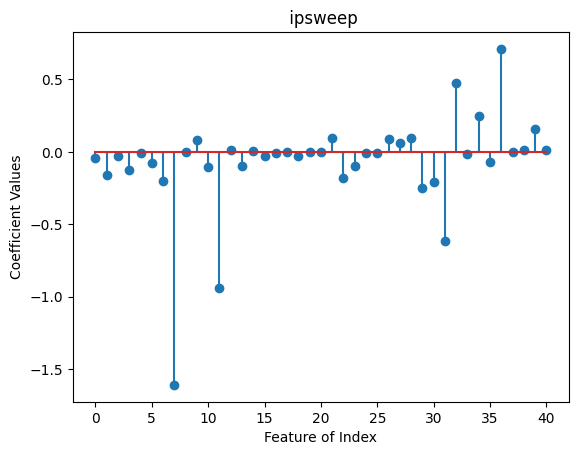

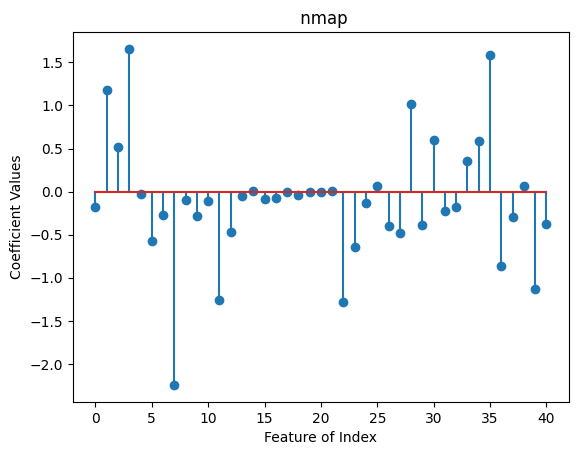

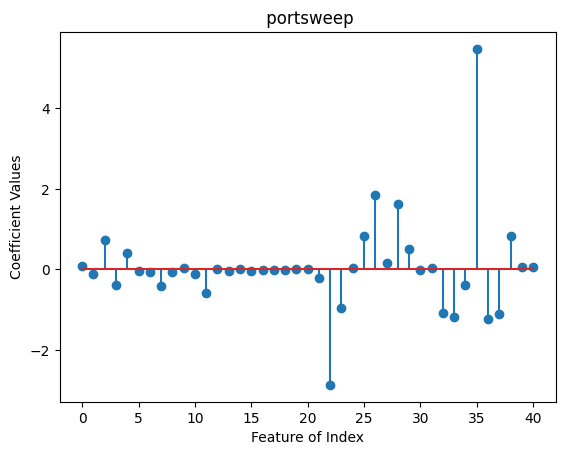

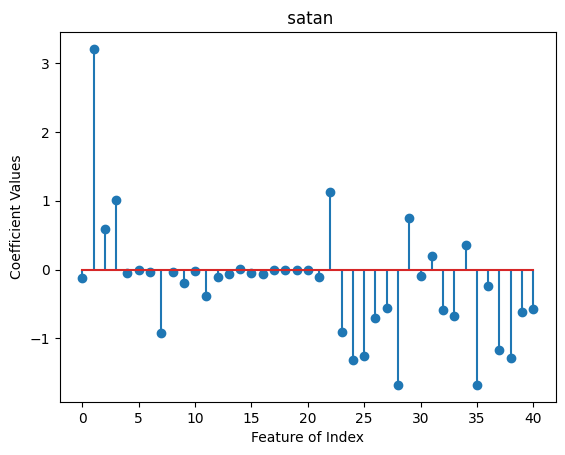

In [7]:
print(len(Xw))


coefficients = []
coefList = [5, 10, 14, 16]


for class_label in coefList:
   
    y_binary = (y == class_label).astype(int)
    
    
    logReg = LogisticRegression(max_iter=100)
    logReg.fit(Xw, y_binary.values.ravel())
    
    
    W = logReg.coef_.flatten()
    
    
    coefficients.append(W)


coefficients = np.array(coefficients)


for i in range(coefficients.shape[0]):
    plt.figure()
    plt.stem(coefficients[i])
    plt.title(f' {IC[coefList[i]]}')
    plt.xlabel('Feature of Index')
    plt.ylabel('Coefficient Values')

    idx1=np.argsort(np.abs(W))[-1]
    idx2=np.argsort(np.abs(W))[-2]
    idx3=np.argsort(np.abs(W))[-3]

    weight =[w_labels[idx1], w_labels[idx2],w_labels[idx3]]
    print(weight)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)


Xs = scale(X_train)

In [9]:
logReg = LogisticRegression(max_iter=100)
logReg.fit(X_train, y_train.values.ravel())



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:

from sklearn.metrics import accuracy_score

y_train = logReg.predict(X_train)
y_test = logReg.predict(X_test)

train_pred = accuracy_score(y_train, y_train)
test_pred = accuracy_score(y_test, y_test)

print("Train scoring: ", train_pred)
print("Test scoring: ", test_pred)



Train scoring:  1.0
Test scoring:  1.0


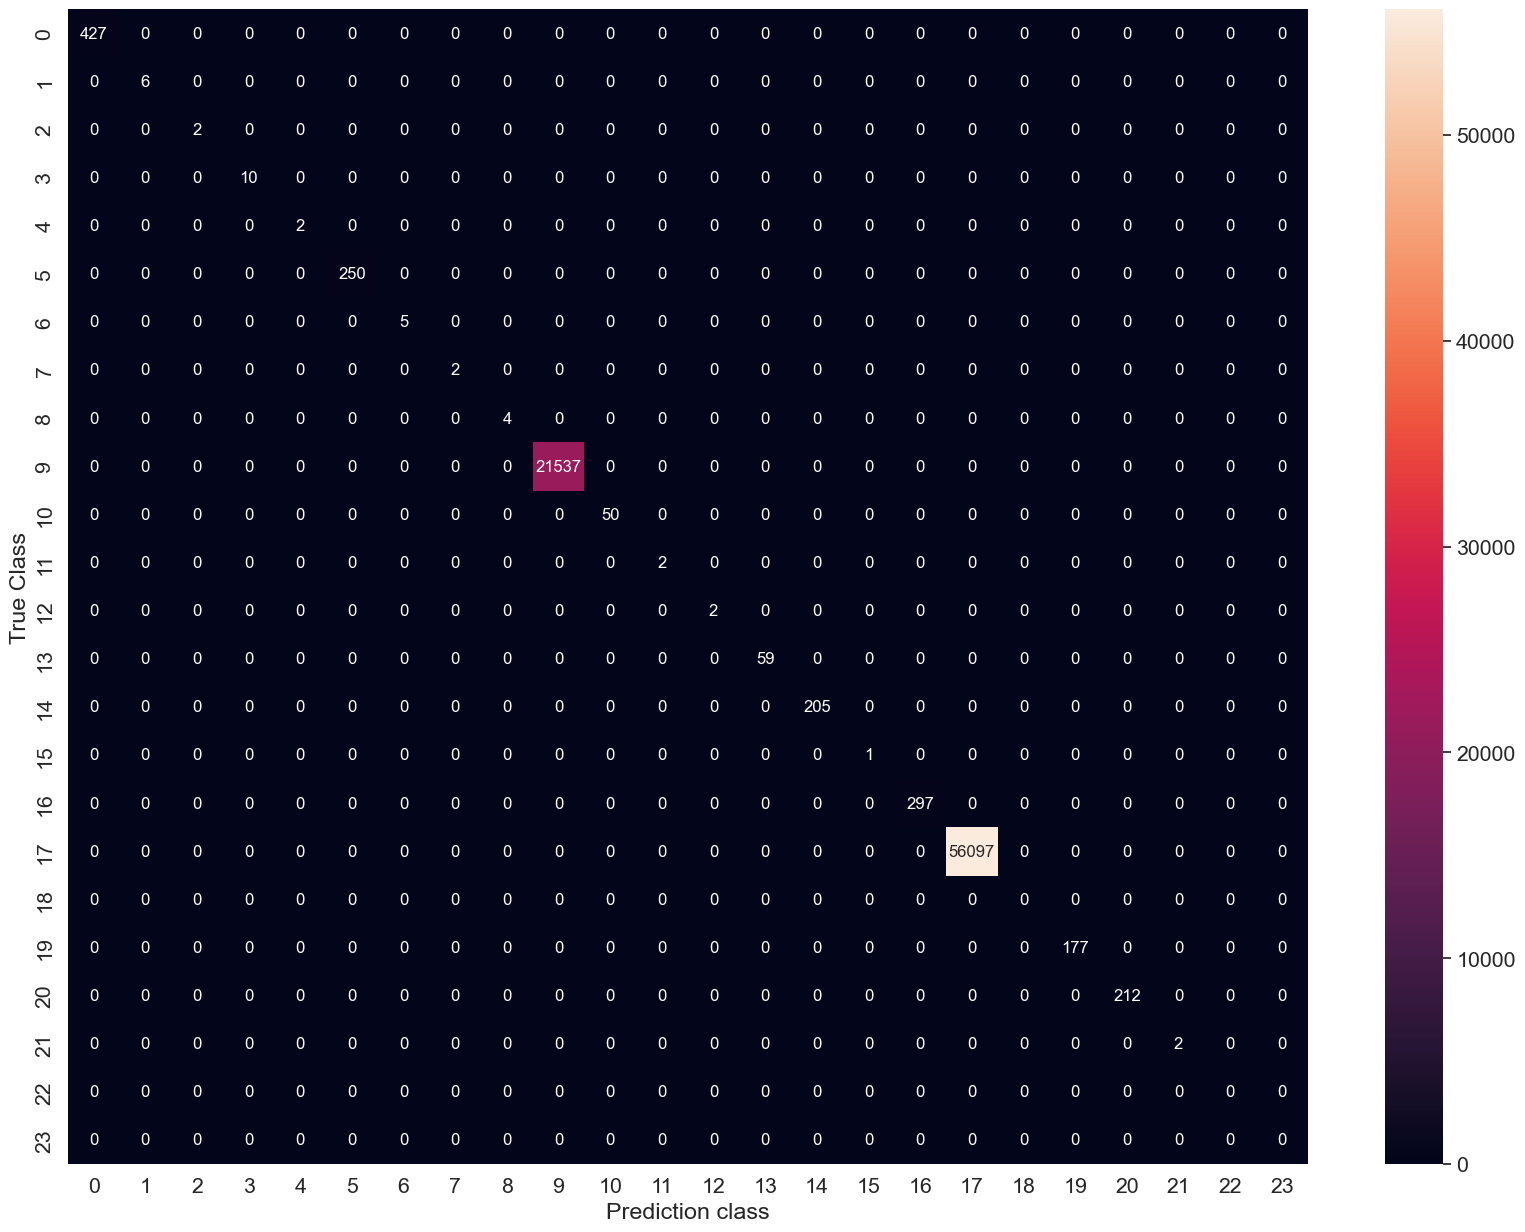

In [11]:

import seaborn as sns
from sklearn.metrics import confusion_matrix


labels1 = ['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']

labels2 = np.arange(24)

C = confusion_matrix(y_test, y_test, labels=labels2)
plt.figure(figsize=(20,15))
sns.set(font_scale=1.4)
sns.heatmap(C, annot=True, annot_kws={"size":12}, fmt='g', xticklabels=labels2, yticklabels=labels2)
plt.ylabel('True Class')
plt.xlabel('Prediction class')
 
plt.show()



# Regularization (L1)
* compare the accuracies for L1 and L2 and plot the feature weights. 

[np.int64(38), np.int64(28), np.int64(24)]
[np.int64(38), np.int64(28), np.int64(24)]
[np.int64(38), np.int64(28), np.int64(24)]
[np.int64(38), np.int64(28), np.int64(24)]


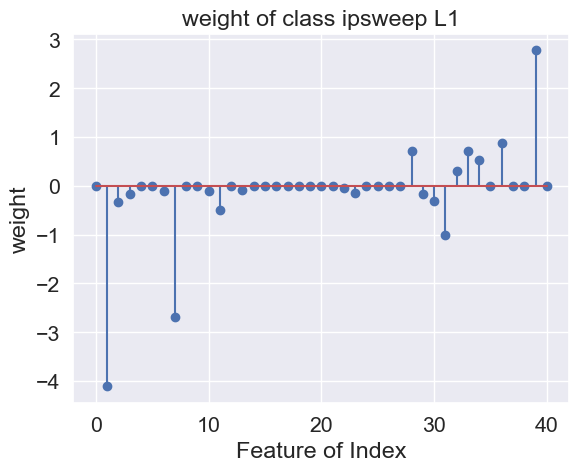

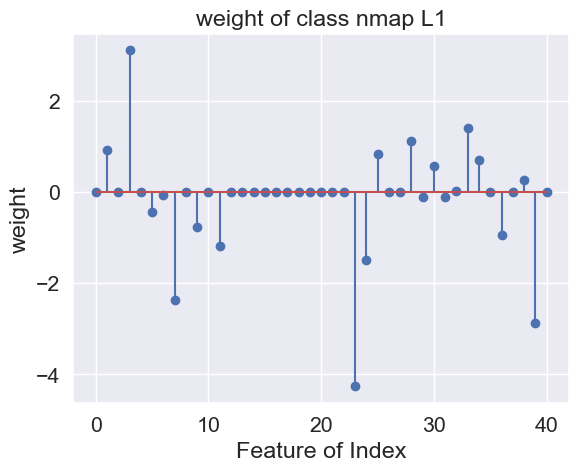

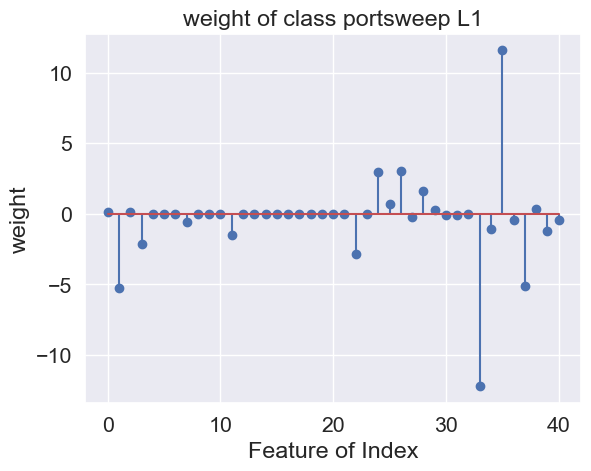

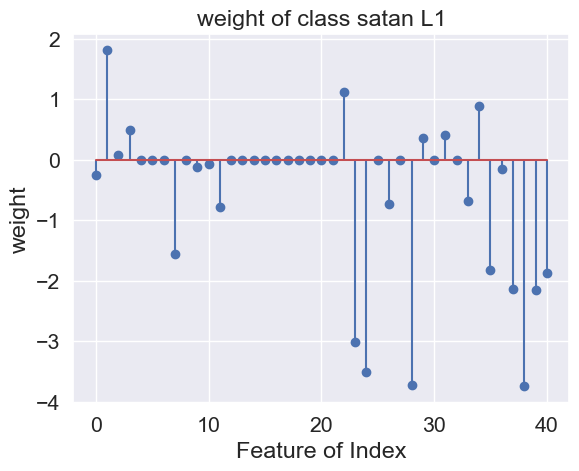

In [12]:

coefficients = []
coefList = [5, 10, 14, 16]
x_labels = w_labels


for class_label in coefList:
    
    y_binary = (y == class_label).astype(int)
    
    
    logReg_w = LogisticRegression(penalty='l1', max_iter=100, solver='liblinear')
    logReg_w.fit(Xw, y_binary.values.ravel())

    W = logReg_w.coef_.flatten()
    
    
    coefficients.append(W)


coefficients = np.array(coefficients)

# Plot the coefficients for each classifier
for i in range(coefficients.shape[0]):
    plt.figure()
    plt.stem(coefficients[i])
    plt.title(f'weight of class {IC[coefList[i]]} L1')
    plt.xlabel('Feature of Index')
    plt.ylabel('weight')

    idx1=np.argsort(np.abs(W))[-1]
    idx2=np.argsort(np.abs(W))[-2]
    idx3=np.argsort(np.abs(W))[-3]

    weight=[x_labels[idx1], x_labels[idx2],x_labels[idx3]]
    print(weight)


In [13]:

logReg = LogisticRegression(penalty='l1', max_iter=100, solver='liblinear')

logReg.fit(X_train, y_train.values.ravel())




AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [ ]:
train_pred = logReg.predict(X_train)
test_pred = logReg.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)

Train score:  1.0
Test score:  1.0


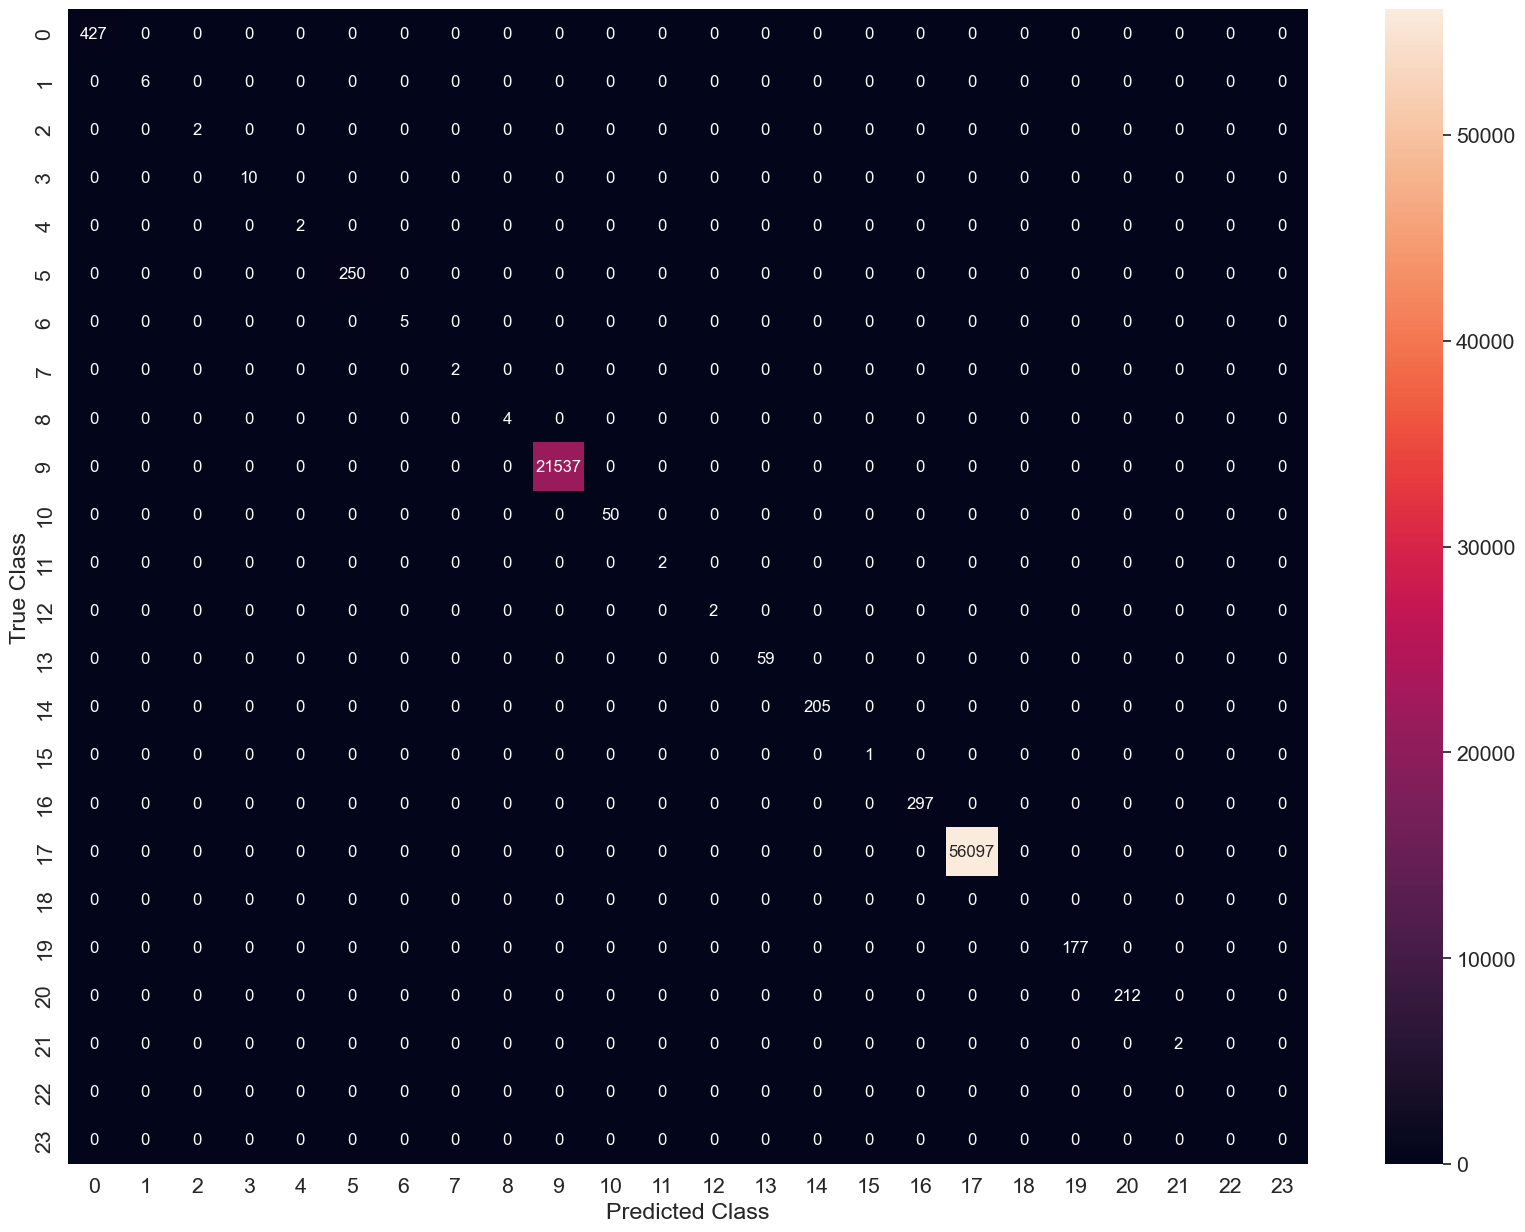

In [ ]:

labels2 = np.arange(24)

C = confusion_matrix(y_test, test_pred, labels=labels2)
plt.figure(figsize=(20,15))
sns.set(font_scale=1.4)
sns.heatmap(C, annot=True, annot_kws={"size":12}, fmt='g', xticklabels=labels2, yticklabels=labels2)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
 
plt.show()



# Regularization {L2}
* we will find out the heaviest weight for specific attacks 

[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]
[np.int64(1), np.int64(28), np.int64(35)]


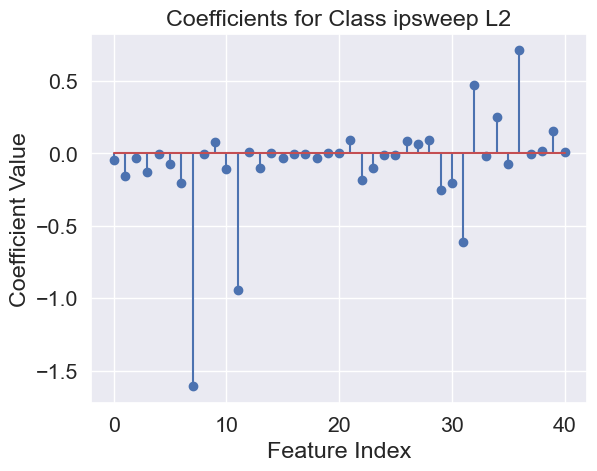

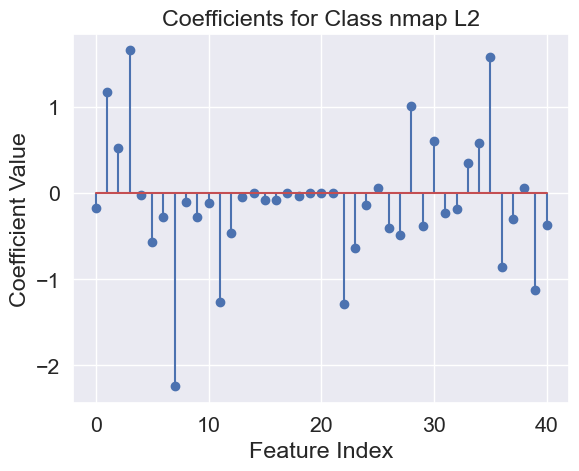

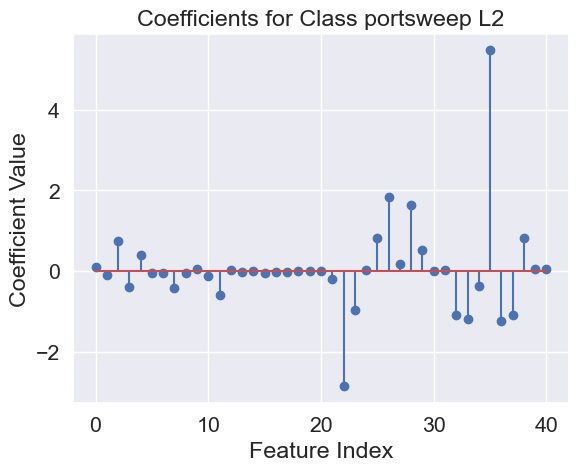

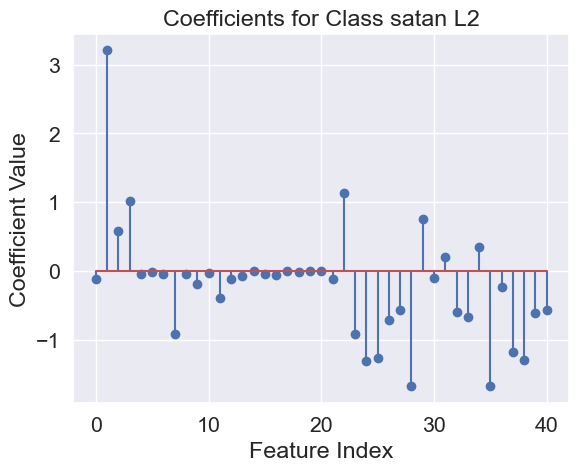

In [ ]:

coefficients = []
coefList = [5, 10, 14, 16]

for class_label in coefList:
   
    y_binary = (y == class_label).astype(int)
    

    logReg_w = LogisticRegression(penalty='l2', max_iter=100)
    logReg_w.fit(Xw, y_binary.values.ravel())
    

    W = logReg_w.coef_.flatten()
    
   
    coefficients.append(W)


coefficients = np.array(coefficients)


for i in range(coefficients.shape[0]):
    plt.figure()
    plt.stem(coefficients[i])
    plt.title(f'Coefficients for Class {IC[coefList[i]]} L2')
    plt.xlabel('Feature Index')
    plt.ylabel('Coefficient Value')

    idx1=np.argsort(np.abs(W))[-1]
    idx2=np.argsort(np.abs(W))[-2]
    idx3=np.argsort(np.abs(W))[-3]

    weight=[x_labels[idx1], x_labels[idx2],x_labels[idx3]]
    print(weight)


In [16]:
from sklearn.linear_model import LogisticRegression
logReg = LogisticRegression(penalty='l2', max_iter=100)

logReg.fit(X_train, y_train.ravel())




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:


train_pred = logReg.predict(X_train)
test_pred = logReg.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)



Train score:  0.99997479473462
Test score:  0.9998487693606725


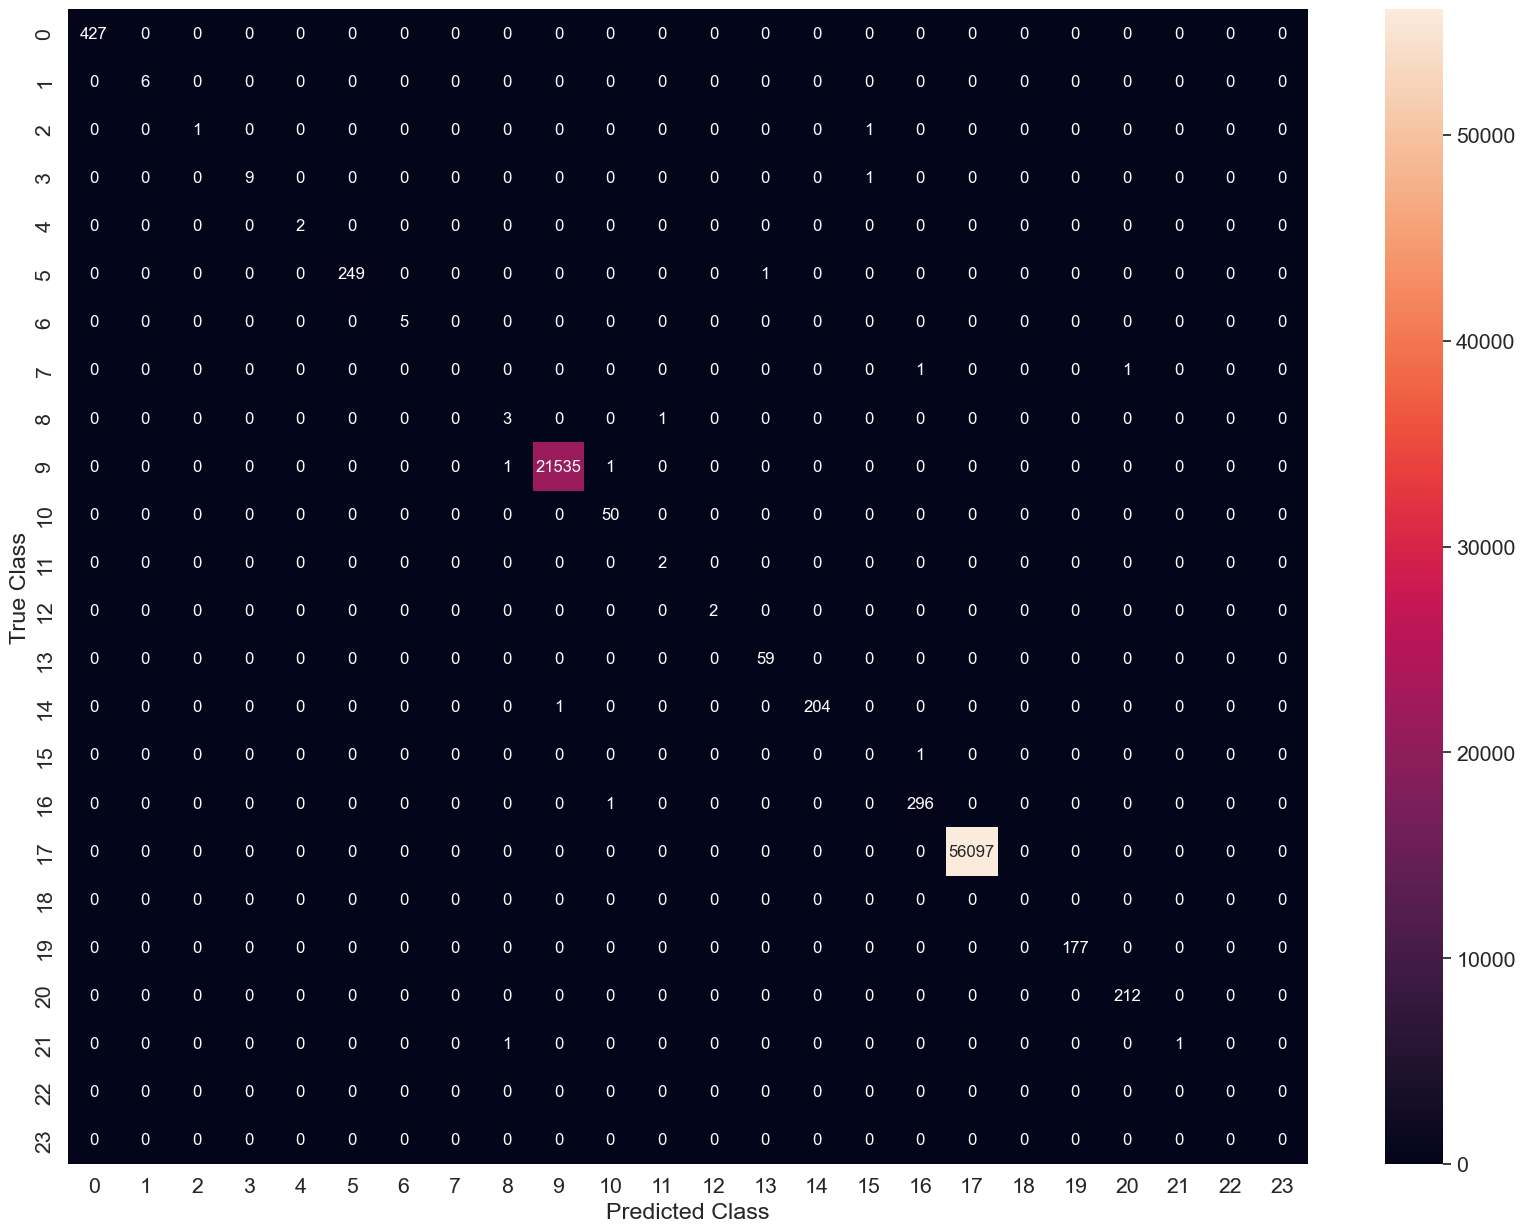

In [21]:
labels = np.arange(24)

C = confusion_matrix(y_test, test_pred, labels=labels)
plt.figure(figsize=(20,15))
sns.set(font_scale=1.4)
sns.heatmap(C, annot=True, annot_kws={"size":12}, fmt='g', xticklabels=labels, yticklabels=labels)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
 
plt.show()

# .001

In [28]:
regu = LogisticRegression(penalty='l2', max_iter=100, C=.001)

regu.fit(X_train, y_train.ravel())

rain_pred = regu.predict(X_train)
test_pred = regu.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)

Train score:  0.99997479473462
Test score:  0.9984498859468929


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# .01 


In [30]:


regu = LogisticRegression(penalty='l2', max_iter=100, C=.01)

regu.fit(X_train, y_train.ravel())

train_pred = regu.predict(X_train)
test_pred = regu.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)



Train score:  0.9997290433971656
Test score:  0.9996597310615131


# .1

In [32]:
regu = LogisticRegression(penalty='l2', max_iter=100, C=.1)

regu.fit(X_train, y_train.ravel())

train_pred = logReg.predict(X_train)
test_pred = logReg.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)

Train score:  0.99997479473462
Test score:  0.9998487693606725


# 1 

In [33]:
regu = LogisticRegression(penalty='l2', max_iter=100, C=1)

regu.fit(X_train, y_train.ravel())

train_pred = regu.predict(X_train)
test_pred = regu.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)


Train score:  0.99997479473462
Test score:  0.9998487693606725


# 10

In [34]:
regu = LogisticRegression(penalty='l2', max_iter=100, C=10)

regu.fit(X_train, y_train.ravel())

train_pred = logReg.predict(X_train)
test_pred = logReg.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)

Train score:  0.99997479473462
Test score:  0.9998487693606725


# 100

In [35]:
regu = LogisticRegression(penalty='l2', max_iter=100, C=100)

regu.fit(X_train, y_train.ravel())

train_pred = logReg.predict(X_train)
test_pred = logReg.predict(X_test)

train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

print("Train score: ", train_score)
print("Test score: ", test_score)

Train score:  0.99997479473462
Test score:  0.9998487693606725
